Dataset Shape: (20640, 10)
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

After dropping NA: (20433, 10)

Mean Absolute E

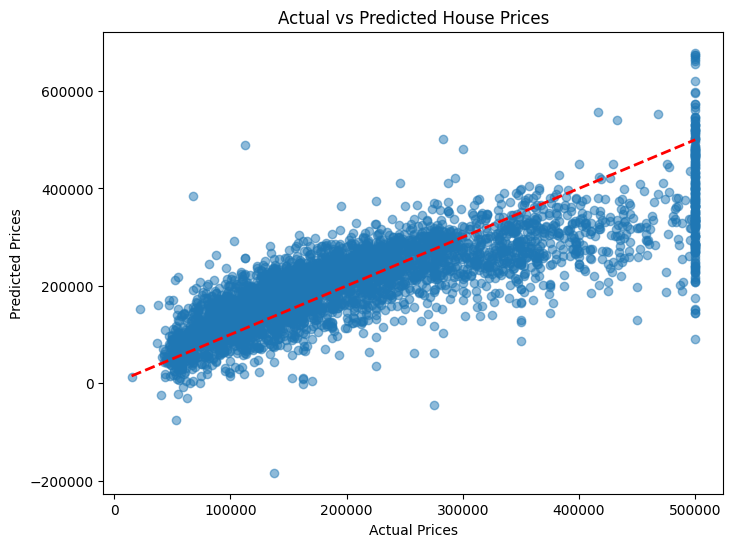


Insight: Linear Regression model predicts house prices using features like income, rooms, location. R² score shows how well features explain price variation.


In [1]:
# Task 6: House Price Prediction using Linear Regression
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Step 1: Dataset load karo
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)
print("Dataset Shape:", df.shape)
print(df.head())

# Step 2: Missing values handle karo
df = df.dropna()
print("\nAfter dropping NA:", df.shape)

# Step 3: Features aur Target alag karo
# ocean_proximity categorical hai, usko encode karna padega
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
X = df_encoded.drop('median_house_value', axis=1)
y = df_encoded['median_house_value']

# Step 4: Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 6: Prediction
y_pred = model.predict(X_test)

# Step 7: Evaluate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nMean Absolute Error: ${mae:.2f}")
print(f"R² Score: {r2:.2f}")

# Step 8: Visualization - Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.show()

# Step 9: Insight
print("\nInsight: Linear Regression model predicts house prices using features like income, rooms, location. R² score shows how well features explain price variation.")